# PROVA PRÁTICA: IMPLEMENTAÇÃO DE REDE NEURAL PARA CLASSIFICAÇÃO

# **Objetivo**
Implementar uma rede neural artificial para classificação usando Python e TensorFlow/Keras que possa classificar espécies de flores de íris com pelo menos 90% de precisão.

**Conjunto de dados:** Conjunto de dados da flor de íris (disponível no scikit-learn)

**Requisitos mínimos:**
Precisão do teste ≥ 90%

O modelo deve usar pelo menos duas camadas ocultas

Deve incluir visualização dos resultados

Enviar código comentado e análise dos resultados

# ENTREGA OBRIGATÓRIA

*   Código Python (.py ou .ipynb) com implementação completa
*   Saída da execução mostrando:
Precisão do treinamento e dos testes,
Relatório de classificação,
Gráficos gerados
*   Breve análise (5 a 10 linhas) explicando os resultados e possíveis melhorias


**Principais funções que você precisará:**

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# **GUIA DE ETAPAS**

# PASSO 1: CONFIGURAÇÃO INICIAL

Importe as bibliotecas necessárias (NumPy, Pandas, Matplotlib, Scikit-learn, TensorFlow/Keras)


In [162]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import  ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# PASSO 2: CARREGAMENTO E EXPLORAÇÃO DE DADOS

Carregue o conjunto de dados Iris do Scikit-Learn usando o codigo  ou baixar desde: https://archive.ics.uci.edu/dataset/53/iris

Examine a forma dos dados (número de amostras, características)

Identifique as características e classes do conjunto de dados

Crie um DataFrame para análise exploratória



In [163]:
# Pode carregar o conjunto de dados Iris diretamente desde Scikit-Learn
# from sklearn.datasets import load_iris # Biblioteca ja importada antes
iris = load_iris()
# Iris é um dataset que contém dados sobre flores e suas espécies
print(iris.keys())

dados = pd.DataFrame(data=iris.data, columns=iris.feature_names)
dados['species'] = iris.target

print("\nQuantidade de amostras: ", len(dados.index))
print("Caracteristicas: ", end='')
for carac in range(len(iris.feature_names)):
    print(f"{carac}. {iris.feature_names[carac]}, ", end='')
    ''' Imprime as características das flores (todas em centimetros):
        sepal length: o comprimento da sepala
        sepal width: a largura da sepala
        petal length: o comprimento da petala
        petal width: a largura da petala
    '''
print("\nEspecies / Classes: ", end='')
for tipo in range(len(iris.target_names)):
    print(f"{tipo} = {iris.target_names.item(tipo)}, ", end='')
    # 0 = setosa, 1 = versicolor, 2 = virginica

print(dados.head()) # mostra uma geral de como os dados são definidos

# Iris: um dataset com informações sobre flores
# iris.data = matriz numpy com as caracteristicas
# iris.target = vetor numpy com as especies de flores, numerados de 0 a 2
# iris.feature_names = lista com os nomes das caracteristicas
# iris.target_names = lista com os nomes das classes (espécies)
# iris.DESCR = descricao do dataset
# iris.frame = dataframe do pandas

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

Quantidade de amostras:  150
Caracteristicas: 0. sepal length (cm), 1. sepal width (cm), 2. petal length (cm), 3. petal width (cm), 
Especies / Classes: 0 = setosa, 1 = versicolor, 2 = virginica,    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


# ETAPA 3: ANÁLISE EXPLORATÓRIA

Exibir estatísticas descritivas (média, desvio padrão, percentis)

Visualizar a distribuição das classes

Criar gráficos de dispersão para visualizar as relações entre as características

Gerar uma matriz de correlação

               sepal length (cm)  sepal width (cm)  petal length (cm)  \
Media                   5.843333          3.057333           3.758000   
Desvio padrao           0.828066          0.435866           1.765298   
1 quartil               5.100000          2.800000           1.600000   
Mediana                 5.800000          3.000000           4.350000   
3 quartil               6.400000          3.300000           5.100000   

               petal width (cm)   species  
Media                  1.199333  1.000000  
Desvio padrao          0.762238  0.819232  
1 quartil              0.300000  0.000000  
Mediana                1.300000  1.000000  
3 quartil              1.800000  2.000000  

Contagem de especies: 
species
0    50
1    50
2    50
Name: count, dtype: int64


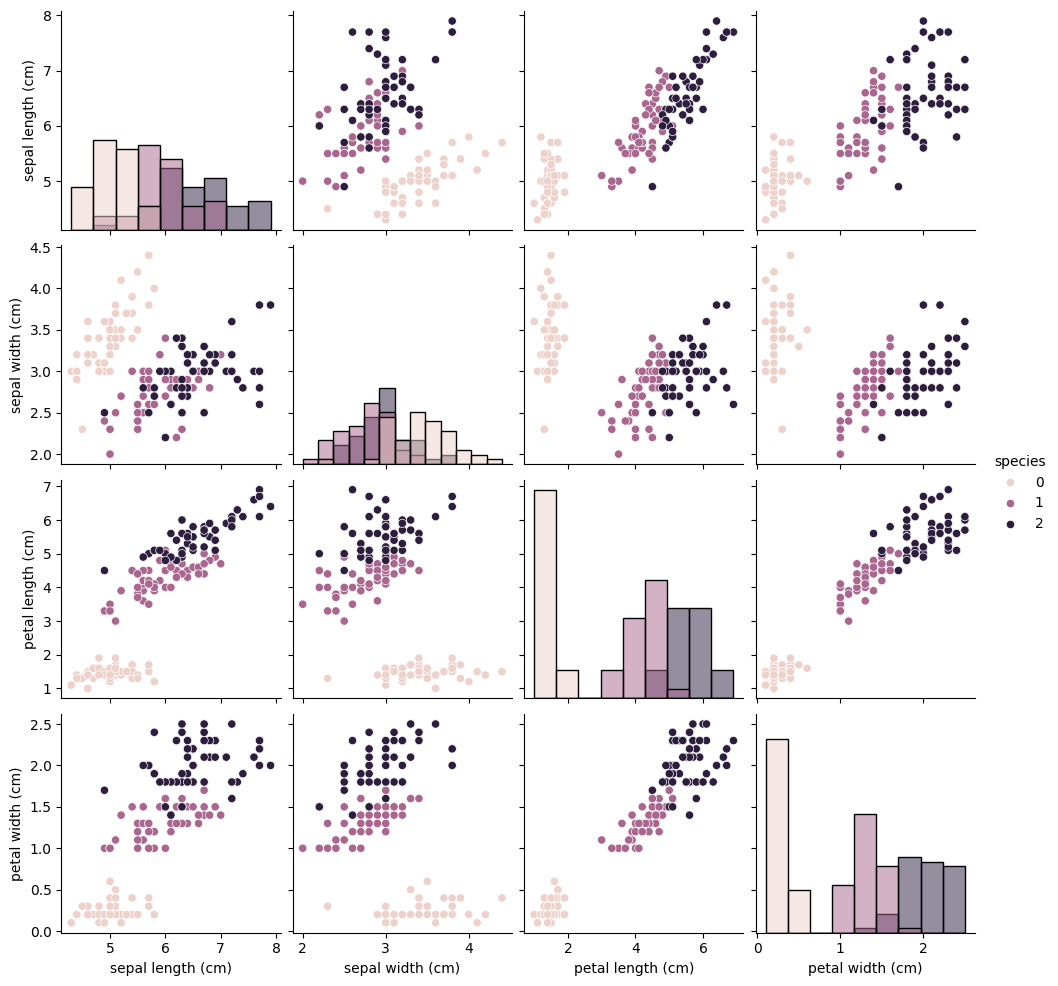

' Com o gráfico de correlação plotado, percebe-se que as características das flores possuem correlações fracas, médias e fortes umas com as outras.\n- Comprimento da sépala: Correlação fraca com a largura da sépala, porém fortes correlações com o comprimento e largura das petalas e da espécie\n- Largura da sépala: Correlação fraca com o comprimento da sépala, porém médias correlações com o comprimento e largura das petalas e da especie\n- Comprimento da petala: Correlacao media com a largura da sepala, porem fortes correlacoes com o comprimento e largura das petalas e da especie\n- Largura da petala: Correlacao media com a largura da sepala, porem fortes correlacoes com o comprimento e largura das petalas e da especie\n'

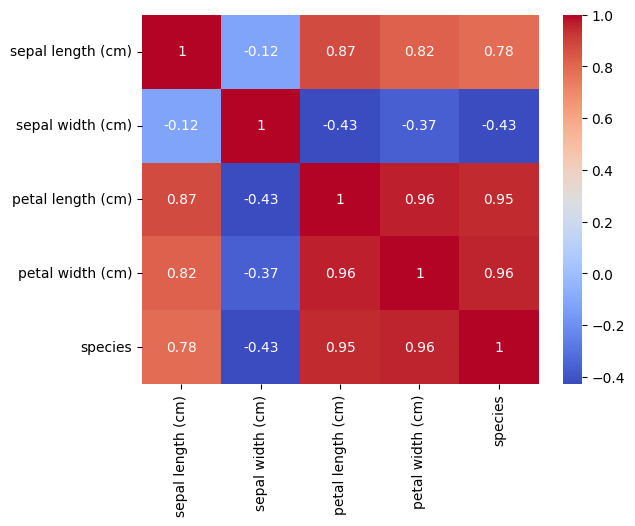

In [164]:
resumo = dados.agg(['mean', 'std', lambda x: x.quantile(0.25), 'median', lambda x: x.quantile(0.75)])
resumo.index = ['Media', 'Desvio padrao', '1 quartil', 'Mediana', '3 quartil']
print(resumo) # aqui eu utilizo uma funcao que junta varias outras funcoes em uma unica tabela

print(f"\nContagem de especies: \n{dados['species'].value_counts()}")

sns.pairplot(dados, hue='species', diag_kind='hist') # pairplot é um conjunto de graficos para vizualizar relacoes entre multiplas variaveis
# Aqui os dados nao estao padronizados ou normalizados
plt.show()

correlacao = dados.corr() 
sns.heatmap(correlacao, annot=True, cmap='coolwarm') # um mapa de correlacao que mostra a correlacao entre todas as caracteristicas

''' Com o gráfico de correlação plotado, percebe-se que as características das flores possuem correlações fracas, médias e fortes umas com as outras.
- Comprimento da sépala: Correlação fraca com a largura da sépala, porém fortes correlações com o comprimento e largura das petalas e da espécie
- Largura da sépala: Correlação fraca com o comprimento da sépala, porém médias correlações com o comprimento e largura das petalas e da especie
- Comprimento da petala: Correlacao media com a largura da sepala, porem fortes correlacoes com o comprimento e largura das petalas e da especie
- Largura da petala: Correlacao media com a largura da sepala, porem fortes correlacoes com o comprimento e largura das petalas e da especie
'''

# PASSO 4: PRÉ-PROCESSAMENTO


Divida os dados em treinamento (80%) e teste (20%) com estratificação

Padronize/Normalize os recursos (CRÍTICO para redes neurais!)

Converta rótulos para codificação one-hot para classificação múltipla

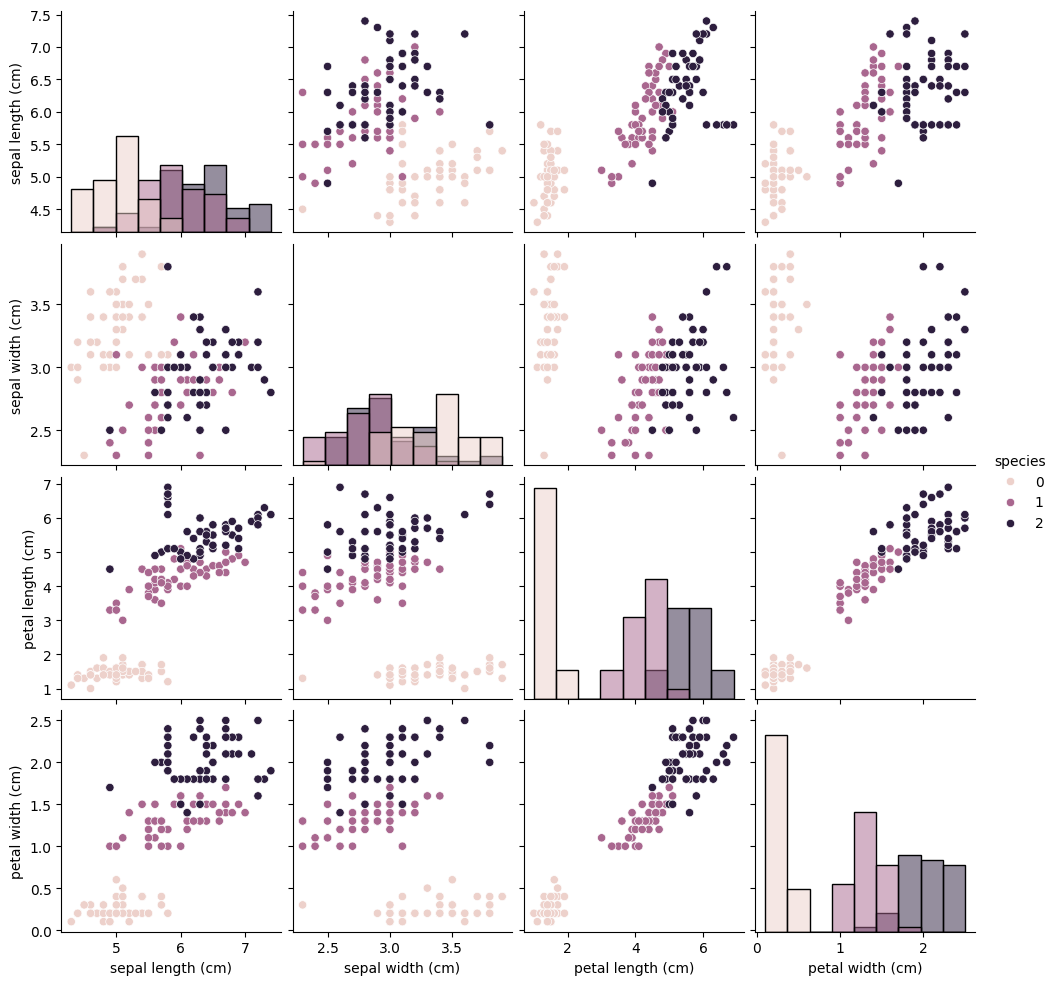

In [165]:
for coluna in dados.columns: # Esse conjunto de códigos normaliza os dados, transformando outliers e quaisquer valores inexistentes na media dos valores
    media_coluna = round(dados[coluna].mean(), 1)
    std_coluna = dados[coluna].std()
    dist_tolerancia = 2 * std_coluna
    upper_outliers = dados[coluna][dados[coluna] > media_coluna + dist_tolerancia]
    lower_outliers = dados[coluna][dados[coluna] < media_coluna - dist_tolerancia]
    outliers = pd.concat([upper_outliers, lower_outliers], ignore_index=True)

    dados.fillna({coluna:media_coluna}, inplace=True)
    dados.loc[dados[coluna].isin(outliers), coluna] = media_coluna

scaler = StandardScaler()
x_data = dados.drop('species', axis=1)
x_data = scaler.fit_transform(x_data) # Essa funcao padroniza os dados, viza garantir que os dados sejam comparaveis e consistentes
y_data = to_categorical(dados['species']) # converte o rotulo "species" para codificacao one hot
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42)

sns.pairplot(dados, hue='species', diag_kind='hist') # Dados normalizados e padronizados
plt.show()

# PASO 5: CONSTRUCCIÓN DEL MODELO

Crie um Modelo Sequencial de Keras

Defina a arquitetura:

Camada de entrada: 4 neurônios (1 por característica)

Mínimo de 2 camadas ocultas com ativação ReLU

Camada de saída: 3 neurônios com ativação Softmax

Construa o modelo com:

Otimizador: Adam

Perda: Entropia cruzada categórica

Métrica: Precisão

In [166]:
modelo = Sequential([
    Dense(8, input_dim=4, activation='relu'),
    Dense(6, activation='relu'),
    Dense(4, activation='relu'),
    Dense(3, activation='softmax')
])

modelo.compile(
    loss='binary_crossentropy',  # função de perda
    optimizer='adam',            # otimizador
    metrics=['precision']        # métrica
)

c:\Users\guilh\Documents\College_Stuff\Inteligencia artificial\Atividades\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# PASSO 6: TREINAMENTO

Treine o modelo com os dados de treinamento

Use validation_split para monitorar o overfitting

Teste com 50 a 100 épocas e um tamanho de lote pequeno (8 a 16)

Salve o histórico de treinamento

In [167]:
historico = modelo.fit(
    x_train, y_train,
    epochs=100,          # número de épocas
    batch_size=12,       # tamanho do batch
    validation_data=(x_test, y_test),  # validação durante o treino
    verbose=1
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.7618 - precision: 0.0000e+00 - val_loss: 0.7479 - val_precision: 0.0000e+00
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7384 - precision: 0.0000e+00 - val_loss: 0.7277 - val_precision: 0.0000e+00
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7190 - precision: 0.0000e+00 - val_loss: 0.7109 - val_precision: 0.0000e+00
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7038 - precision: 0.0000e+00 - val_loss: 0.6967 - val_precision: 0.0000e+00
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6910 - precision: 0.0000e+00 - val_loss: 0.6857 - val_precision: 0.0000e+00
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6808 - precision: 0.0000e+00 - val_loss: 0.6772 - val_precision: 0.0000e+00
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6730 - precision: 0.0000e+00 - val_loss: 0.6693 - val_precision: 0.0000e+00
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0

PASSO 7: AVALIAÇÃO

Calcule a precisão no conjunto de teste

Gere o relatório de classificação (precisão, recall, pontuação F1)

Crie a matriz de confusão

Trace a evolução da perda e da precisão durante o treinamento

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Perda no teste: 0.0428
Acurácia no conjunto de teste: 1.0000

Relatorio de classificacao: 
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

--- Matriz de Confusão ---


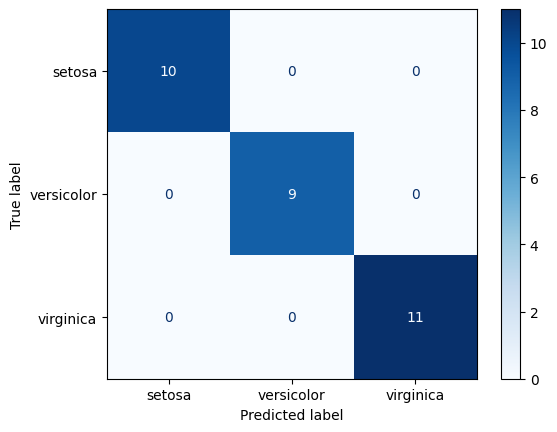

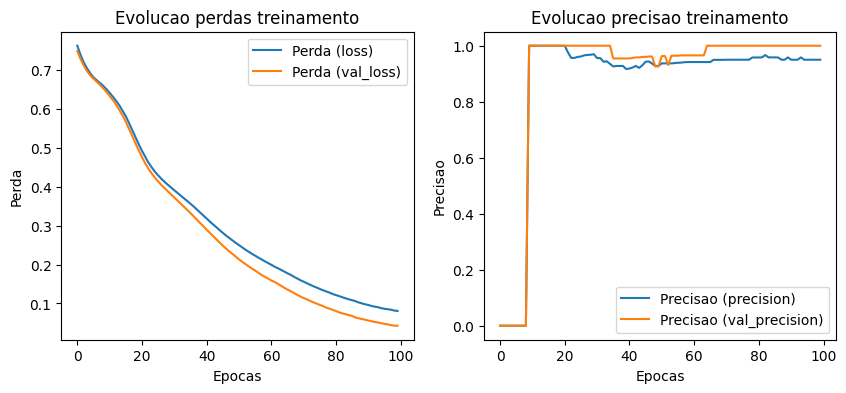

In [ ]:
y_pred = modelo.predict(x_test)
y_pred_labels = np.argmax(y_pred, axis=1) # Transforma os dados codificados em One Hot de volta para valores compreensiveis pelas funcoes
y_test_labels = np.argmax(y_test, axis=1)

loss, acc = modelo.evaluate(x_test, y_test, verbose=0)
print(f"Perda no teste: {loss:.4f}")
print(f"Acurácia no conjunto de teste: {acc:.4f}")
print(f"\nRelatorio de classificacao: \n{classification_report(y_test_labels, y_pred_labels, target_names=iris.target_names)}")


# A Matriz de Confusão nos mostra exatamente onde o modelo acertou e errou, comparando os valores previstos com valores reais.
print("--- Matriz de Confusão ---")
cm = confusion_matrix(y_test_labels, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.show()

fig, (axs1, axs2) = plt.subplots(1, 2) # gráficos das evoluções de perda e precisao
fig.set_figheight(4)
fig.set_figwidth(10)
axs1.plot(historico.history['loss'], label='Perda (loss)') # a funcao history armazena todos os dados durante o treinamento
axs1.plot(historico.history['val_loss'], label='Perda (val_loss)')
axs1.legend()
axs1.set_title("Evolucao perdas treinamento")
axs1.set_xlabel("Epocas")
axs1.set_ylabel("Perda")
axs2.plot(historico.history['precision'], label='Precisao (precision)')
axs2.plot(historico.history['val_precision'], label='Precisao (val_precision)')
axs2.legend()
axs2.set_title("Evolucao precisao treinamento")
axs2.set_xlabel("Epocas")
axs2.set_ylabel("Precisao")
plt.show()

# PASSO 8: ANÁLISE E CONCLUSÕES

Interpretar os resultados da matriz de confusão

Identificar overfiting

Sugerir melhorias para o modelo

Conclusões sobre o desempenho

A partir dos resultados da matriz de confusao, o modelo treinado conseguiu obter uma ótima acurácia nos conjuntos de testes, visto que em todos os valores analisados, o modelo conseguiu prever todos com sucesso, já que não existem casos de respostas erradas, ou seja, de diferente classe. A partir da análise dos gráficos de evolucao no treinamento do modelo, é possível perceber que os valores de perda e validação no treinamento estão seguindo corretamente o modelo, o que indica que não há overfitting, porém, na evolução do treinamento, dá para ver que enquanto o valor da precisão fica se alterando, o valor da precisão na validação se estagna, sendo um possível indicativo de overfitting. Isso ocorre porque o modelo acaba aprendendo tanto os padroes gerais dos dados que acaba memorizando detalhes específicos no treino que não existem na validação. Sendo assim, possíveis soluções para esse problema seria o aumento da quantidade de dados, parar o treinamento do modelo quando a validação parar de melhorar (EarlyStopping) ou reduzir a complexidade do modelo, retirando o excesso de neurônios nas camadas do modelo sequencial.
Sendo assim, o modelo teve bom desempenho nos treinamentos e conseguiu prever com sucesso casos de teste atribuídos a ele, contudo o modelo é ligeiramente complexo para a complexidade dos dados, porém não afeta tanto o modelo.